# Superstore Retail Analytics - Feature Engineering

**Continuing from:** `exploring_cleaning_data.ipynb` — this notebook picks up once the data is *clean*, and turns it into something that can actually answer business questions.

**Workflow:**

This is the same repeatable process regardless of the dataset — the checklist we'll apply to the Superstore data in Part 2 below.

1. **Define the Analysis Questions** — write down what we're trying to answer *before* building features, so every feature has a reason to exist.
2. **Feature Engineering — Derived Columns** — transform existing columns (dates, numeric ratios, categorical cleanup) into new per-row signal.
3. **Feature Engineering — Aggregated Features** — roll row-level data up into entity-level features (per customer, per product, etc.).
4. **Exploratory Data Analysis** — univariate → bivariate → multivariate, in that order.
5. **Answering the Questions** — go back to Step 1 and directly resolve each question with a specific table or aggregation.
6. **Insight Synthesis** — summarize findings in plain language, including caveats inherited from cleaning decisions.
7. **Handoff Prep** — name and preserve the tables/features the next stage (visualization) will need.

In [20]:
# Importing the proper and required data packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow
import squarify
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
# Reading the clean data and make a copy of the original file to be the single source of truth
df = pd.read_parquet("Sample-Superstore2019_cleaned.parquet", engine="pyarrow")
df.shape

(9986, 21)

In [3]:
# Creating the copy of the original DataFrame
df_clean = df.copy()

### Step 1 — Define the Analysis Questions

1. Which `State` generates the most total `Profit`, and which generates the biggest total loss?
2. Is there a relationship between `Discount` and `Profit`?
3. Does `Ship Mode` relate to profitability or shipping time?
4. Is there seasonality in `Sales` — by month, or by day of week?
5. Who are the most valuable customers, and how would we segment them by RFM modle?

    Which customer segments generate the highest revenue ?, 
    Which RFM segment generates the highest profit ?, 
    Which segments should receive retention campaigns ?, 
    Which segments should receive upselling or cross-selling offers?
6. Is sales related to time?

    How do Sales change over the Years?, 
    How do Sales vary across quarters and Months?, 
    How do Sales differ between Weekdays and Weekends?

7. Did shipping days affect on any column?

    What is the relationship between the Number of Orders and Shipping Days?,
    How do Shipping Days vary across different Shipping Modes?,
    How do Shipping Days vary across different Regions?,
    What is the relationship between Shipping Days and Profit?

8. How does Profit Margin vary across different Categories?
9. What is the relationship between Profit Margin and Quantity?
10. How does Profit Margin vary across different Customer Segments?
11. How does Profit vary across different Customer Segments?
13. How does Sales per Unit vary across different Customer Segments?
14. What is the relationship between Sales per Unit and Quantity?
15. Which Products have the highest Profit per Unit?

### Step 2 — Feature Engineering: Derived Columns


In [4]:
# Date-based features -- needed for the seasonality question (Q4)
df_clean["Shipping Days"] = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days
df_clean.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [5]:

df_clean["Order Weekday"] = df_clean["Order Date"].dt.day_name()
df_clean["Order Month"] = df_clean["Order Date"].dt.month
df_clean["Order Quarter"] = df_clean["Order Date"].dt.quarter
df_clean["Order Year"] = df_clean["Order Date"].dt.year
df_clean["Is Weekend"] = df_clean["Order Date"].dt.dayofweek >= 5

df_clean[["Order Date", "Ship Date", "Shipping Days", "Order Weekday", "Is Weekend"]].head()

,Order Date,Ship Date,Shipping Days,Order Weekday,Is Weekend
0,2018-11-08,2018-11-11,3,Thursday,False
1,2018-11-08,2018-11-11,3,Thursday,False
2,2018-06-12,2018-06-16,4,Tuesday,False
3,2017-10-11,2017-10-18,7,Wednesday,False
4,2017-10-11,2017-10-18,7,Wednesday,False


In [6]:
# Numeric transforms -- needed for the discount question (Q2)
df_clean["Unit Price"] = df_clean["Sales"] / df_clean["Quantity"]
df_clean["Profit Per Unit"] = df_clean["Profit"] / df_clean["Quantity"]
df_clean["Profit Margin"] = (df_clean["Profit"] / df_clean["Sales"])*100
df_clean[["Product ID", "Sales", "Unit Price", "Profit Per Unit", "Profit Margin", "Profit"]].head()

,Product ID,Sales,Unit Price,Profit Per Unit,Profit Margin,Profit
0,FUR-BO-10001798,261.9600,130.9800,20.9568,16.00,41.9136
1,FUR-CH-10000454,731.9400,243.9800,73.1940,30.00,219.5820
2,OFF-LA-10000240,14.6200,7.3100,3.4357,47.00,6.8714
3,FUR-TA-10000577,957.5775,191.5155,-76.6062,-40.00,-383.0310
4,OFF-ST-10000760,22.3680,11.1840,1.2582,11.25,2.5164


In [7]:

# Discount buckets: 0 = no discount, then Low/Medium/High bands.
# Bins chosen from the actual observed range (0.0 to 0.8).
df_clean["Discount Bucket"] = pd.cut(
    df_clean["Discount"],
    bins=[-0.01, 0, 0.2, 0.5, 0.8, 1.0],
    labels=["None", "Low", "Medium", "High", "Very High"],
)

df_clean[["Sales", "Quantity", "Unit Price", "Profit", "Profit Margin", "Discount", "Discount Bucket"]].head()

,Sales,Quantity,Unit Price,Profit,Profit Margin,Discount,Discount Bucket
0,261.9600,2,130.9800,41.9136,16.00,0.00,None
1,731.9400,3,243.9800,219.5820,30.00,0.00,None
2,14.6200,2,7.3100,6.8714,47.00,0.00,None
3,957.5775,5,191.5155,-383.0310,-40.00,0.45,Medium
4,22.3680,2,11.1840,2.5164,11.25,0.20,Low


### Step 3 — Feature Engineering: Aggregated Features


In [8]:
# One row per customer: order count, spend, average order value, tenure
customer_features = df_clean.groupby("Customer ID", observed=True).agg(
    order_count=("Order ID", "nunique"),
    total_spend=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_order_value=("Sales", "mean"),
    first_order=("Order Date", "min"),
    last_order=("Order Date", "max"),
)
customer_features.sort_values("Customer ID", ascending=True).head()

,order_count,total_spend,total_profit,avg_order_value,first_order,last_order
Customer ID,,,,,,
AA-10315,5,5563.560,-362.8825,505.778182,2016-03-31,2019-06-29
AA-10375,9,1056.390,277.3824,70.426000,2016-04-21,2019-12-11
AA-10480,4,1790.512,435.8274,149.209333,2016-05-04,2019-04-15
AA-10645,6,5086.935,857.8033,282.607500,2016-06-22,2019-11-05
AB-10015,3,886.156,129.3465,147.692667,2016-02-18,2018-11-10


In [9]:
# Tenure = span between a customer's first and last order in this dataset 
customer_features["Customer Tenure Days"] = (
    customer_features["last_order"] - customer_features["first_order"]
).dt.days

customer_features.sort_values("total_spend", ascending=False).head()

,order_count,total_spend,total_profit,avg_order_value,first_order,last_order,Customer Tenure Days
Customer ID,,,,,,,
SM-20320,5,25043.050,-1980.7393,1669.536667,2016-03-18,2019-10-12,1303
TC-20980,5,19052.218,8981.3239,1587.684833,2016-11-07,2018-11-26,749
RB-19360,6,15117.339,6976.0959,839.852167,2018-04-01,2019-09-25,542
TA-21385,4,14595.620,4703.7883,1459.562000,2016-09-12,2019-10-22,1135
AB-10105,10,14473.571,5444.8055,723.678550,2016-12-20,2019-11-19,1064


In [10]:
# One row per product: units sold, revenue, average discount given
product_features = df_clean.groupby("Product ID", observed=True).agg(
    product_name=("Product Name", "first"),
    total_qty_sold=("Quantity", "sum"),
    total_revenue=("Sales", "sum"),
    avg_discount=("Discount", "mean"),
).sort_values("total_revenue", ascending=False)

product_features.head()

,product_name,total_qty_sold,total_revenue,avg_discount
Product ID,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,20,61599.824,0.12
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,31,27453.384,0.24
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,6,22638.480,0.50
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,39,21870.576,0.20
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,37,19823.479,0.30


In [11]:
# RFM: Recency (days since last order), Frequency (distinct orders),
# Monetary (total Sales). Recency is measured against the day after the
# last order in the whole dataset, since we have no "today" to measure from.
snapshot_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2019-12-31 00:00:00')

In [26]:
rfm = df_clean.groupby("Customer ID", observed=True).agg(
    Customer_ID=("Customer ID", "first"),
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
)

rfm.sort_values("Monetary", ascending=False).head()

,Customer_ID,Recency,Frequency,Monetary
Customer ID,,,,
SM-20320,SM-20320,80,5,25043.050
TC-20980,TC-20980,400,5,19052.218
RB-19360,RB-19360,97,6,15117.339
TA-21385,TA-21385,70,4,14595.620
AB-10105,AB-10105,42,10,14473.571


In [27]:
rfm[['Recency', 'Frequency', 'Monetary']].describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,793.0,147.769231,186.091317,1.000,31.00,76.000,184.000,1165.00
Frequency,793.0,6.316520,2.550885,1.000,5.00,6.000,8.000,17.00
Monetary,793.0,2894.715728,2627.001533,4.833,1146.05,2256.394,3785.276,25043.05


In [28]:
def score_metric(series, ascending, q=5):
    # Converts a series of values into scores from 1 to q using quintiles.
    # ascending=True  -> larger values get the higher score (used for Frequency, Monetary)
    # ascending=False -> smaller values get the higher score (used for Recency)
    ranked = series.rank(method='first', ascending=ascending)
    return pd.qcut(ranked, q=q, labels=range(1, q + 1)).astype(int)

rfm['R_Score'] = score_metric(rfm['Recency'],   ascending=False)
rfm['F_Score'] = score_metric(rfm['Frequency'], ascending=True)
rfm['M_Score'] = score_metric(rfm['Monetary'],  ascending=True)

rfm['RFM_Score'] = (rfm['R_Score'].astype(str)
                     + rfm['F_Score'].astype(str)
                     + rfm['M_Score'].astype(str))
rfm['RFM_Total'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

rfm.head()


,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
Customer ID,,,,,,,,,
AA-10315,AA-10315,185,5,5563.560,2,2,5,225,9
AA-10375,AA-10375,20,9,1056.390,5,5,2,552,12
AA-10480,AA-10480,260,4,1790.512,1,1,3,113,5
AA-10645,AA-10645,56,6,5086.935,3,3,5,335,11
AB-10015,AB-10015,416,3,886.156,1,1,1,111,3


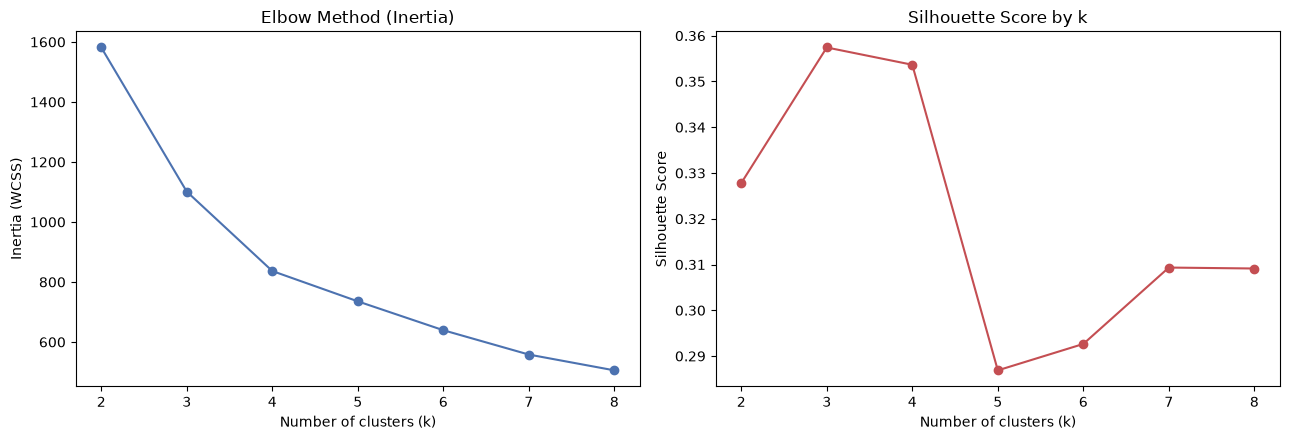

k=2 -> silhouette=0.328
k=3 -> silhouette=0.357
k=4 -> silhouette=0.354
k=5 -> silhouette=0.287
k=6 -> silhouette=0.293
k=7 -> silhouette=0.309
k=8 -> silhouette=0.309


In [29]:
X = rfm[['Recency', 'Frequency', 'Monetary']]
X_scaled = StandardScaler().fit_transform(X)

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#C44E52')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f"k={k} -> silhouette={s:.3f}")

In [33]:
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('Customer_ID', 'count'),  # Updated column name
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')   # Make sure this column name is also correct
)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,296,71.925676,8.513514,3229.768212
1,96,559.218750,3.697917,1469.290101
2,70,119.342857,8.242857,9199.812694
3,331,102.271903,4.703927,1675.104058


In [34]:
# Interpretive segment names based on relative cluster value (Avg_RFM_Total) --
# a widely-used naming convention in RFM literature
segment_names = ['Champions (best customers)', 'Loyal / Potential (loyal & promising customers)',
                  'At Risk (customers likely to churn)', 'Lost / Low-Value (weak or lost customers)']

ordered_clusters = cluster_profile.index.tolist()
cluster_to_segment = dict(zip(ordered_clusters, segment_names[:len(ordered_clusters)]))

rfm['Segment'] = rfm['Cluster'].map(cluster_to_segment)
cluster_profile['Segment'] = cluster_profile.index.map(cluster_to_segment)
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Segment
Cluster,,,,,
0,296,71.925676,8.513514,3229.768212,Champions (best customers)
1,96,559.218750,3.697917,1469.290101,Loyal / Potential (loyal & promising customers)
2,70,119.342857,8.242857,9199.812694,At Risk (customers likely to churn)
3,331,102.271903,4.703927,1675.104058,Lost / Low-Value (weak or lost customers)


In [ ]:
df_clean.to_parquet("Sample-Superstore2019_prepared.parquet", engine="pyarrow", index=False)
rfm.to_parquet("Sample-Superstore2019_rfm.parquet", engine="pyarrow", index=False)